# Setup

In [6]:
!pip install numpy noisereduce

In [7]:
import sys
import os
import shutil
import pickle
import numpy as np
import shutil
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.preprocessing import LabelEncoder
import importlib


In [9]:
# Configuration
INPUT_DATASET_PATH = "/kaggle/input/datasets/alieldinalaa/nn-cmp27-dataset"  # Path to original dataset
OUTPUT_BASE_PATH = '/kaggle/working/processed_data'
BATCH_SIZE = 32
NUM_EPOCHS = 75
NUM_FOLDS = 10

In [15]:

sys.path.append("/kaggle/input/datasets/esraahassan0/preprocess")
sys.path.append("/kaggle/input/datasets/esraahassan0/model-v0")
sys.path.append("/kaggle/input/datasets/esraahassan0/dataloader")
sys.path.append("/kaggle/input/datasets/esraahassan0/feature-extraction-v0")
sys.path.append("/kaggle/input/datasets/esraahassan0/utils-v0")

### Uncomment to copy folders to Working directory 

In [45]:
# shutil.copytree(
#     "/kaggle/input/datasets/esraahassan0/model-v0",
#     "/kaggle/working/model_v0"
# )
# shutil.copytree(
#     "/kaggle/input/datasets/esraahassan0/train-v0",
#     "/kaggle/working/train_v0"
# )
# shutil.copytree(
#     "/kaggle/input/datasets/esraahassan0/dataloader",
#     "/kaggle/working/dataloader"
# )
# shutil.copytree(
#     "/kaggle/input/datasets/esraahassan0/utils-v0",
#     "/kaggle/working/utils_v0"
# )

'/kaggle/working/train_v0'

### Uncomment to delete file from working directory

In [12]:
# import os

# os.remove("/kaggle/working/processed_data/train/train_data.pkl")

### Uncomment to delete dir from working directory

In [44]:
# import shutil

# shutil.rmtree("/kaggle/working/train_v0")

In [46]:
from preprocess import preprocess_single_audio, get_audio_files
import feature_extraction
from feature_extraction.MFCC import MfccExtractor
import model_v0, train_v0.train
from model import AudioClassifier
# Force reload the module from disk
importlib.reload(train_v0.train)
from train_v0.train import Trainer
import train_v0.test
from train_v0.test import ModelEvaluator
from utils import get_all_audio_files_with_labels, load_features_and_labels, inspect_pkl, process_and_save_files

In [25]:

TRAIN_PATH = os.path.join(OUTPUT_BASE_PATH, 'train')
TEST_PATH = os.path.join(OUTPUT_BASE_PATH, 'test')
VAL_PATH = os.path.join(OUTPUT_BASE_PATH, 'validation')

TEST_SIZE = 0.15  # 15% for test
VAL_SIZE = 0.15  # 15% of train for validation

# Create output directories
os.makedirs(TRAIN_PATH, exist_ok=True)
os.makedirs(TEST_PATH, exist_ok=True)
os.makedirs(VAL_PATH, exist_ok=True)

print(f"Output base: {OUTPUT_BASE_PATH}")
print(f"Train: {TRAIN_PATH}")
print(f"Test: {TEST_PATH}")
print(f"Validation: {VAL_PATH}")

Output base: /kaggle/working/processed_data
Train: /kaggle/working/processed_data/train
Test: /kaggle/working/processed_data/test
Validation: /kaggle/working/processed_data/validation


In [27]:
# Get all files
all_files = get_all_audio_files_with_labels(INPUT_DATASET_PATH)
print(f"Total audio files found: {len(all_files)}")

# Show class distribution
from collections import Counter
class_counts = Counter([label for _, label in all_files])
print("\nClass distribution:")
for cls, count in sorted(class_counts.items()):
    print(f"  {cls}: {count}")

Total audio files found: 56236

Class distribution:
  Machine 1_Abnormal: 3176
  Machine 1_Normal: 16200
  Machine 2_Abnormal: 3240
  Machine 2_Normal: 16200
  Machine 3_Abnormal: 3020
  Machine 3_Normal: 14400


In [28]:
# Split into train, test, validation
# First split: train vs test
train_files, test_files = train_test_split(
    all_files, 
    test_size=TEST_SIZE, 
    random_state=42,
    stratify=[label for _, label in all_files]
)

# Second split: train vs validation
train_files, val_files = train_test_split(
    train_files, 
    test_size=VAL_SIZE, 
    random_state=42,
    stratify=[label for _, label in train_files]
)

print(f"Train files: {len(train_files)}")
print(f"Test files: {len(test_files)}")
print(f"Validation files: {len(val_files)}")

Train files: 40630
Test files: 8436
Validation files: 7170


In [30]:
# Initialize MFCC extractor
mfcc_extractor = MfccExtractor(
    sample_rate=16000,
    n_fft=2048,
    n_mels=40,
    hop_length=2048,
    n_mfcc=40
)

## Process data for the first time

In [ ]:
# # Process training data
# print("Processing training data...")
# train_features, train_labels = process_and_save_files(train_files, TRAIN_PATH, mfcc_extractor)
# print(f"Processed {len(train_features)} training samples")

In [ ]:
# # Process test data
# print("Processing test data...")
# test_features, test_labels = process_and_save_files(test_files, TEST_PATH, mfcc_extractor)
# print(f"Processed {len(test_features)} test samples")

In [ ]:
# # Process validation data
# print("Processing validation data...")
# val_features, val_labels = process_and_save_files(val_files, VAL_PATH, mfcc_extractor)
# print(f"Processed {len(val_features)} validation samples")

## Save processed data

In [ ]:
# # Save training data
# with open(os.path.join(OUTPUT_BASE_PATH, 'train/train_data.pkl'), 'wb') as f:
#     pickle.dump({'features': train_features, 'labels': train_labels}, f)

# # Save test data
# with open(os.path.join(OUTPUT_BASE_PATH, 'test/test_data.pkl'), 'wb') as f:
#     pickle.dump({'features': test_features, 'labels': test_labels}, f)

# Save validation data
# with open(os.path.join(OUTPUT_BASE_PATH, 'validation/val_data.pkl'), 'wb') as f:
#     pickle.dump({'features': val_features, 'labels': val_labels}, f)

# print(f"\nData saved to {OUTPUT_BASE_PATH}")

In [11]:
# # Verify data shapes
# print("Data Summary:")
# print(f"Train: {len(train_features)} samples")
# if train_features:
#     print(f"  Feature shape: {train_features[0].shape if hasattr(train_features[0], 'shape') else 'N/A'}")

# print(f"Test: {len(test_features)} samples")
# if test_features:
#     print(f"  Feature shape: {test_features[0].shape if hasattr(test_features[0], 'shape') else 'N/A'}")

# print(f"Validation: {len(val_features)} samples")
# if val_features:
#     for i in range(1,2):
#         print(f"  Feature shape: {val_features[i].shape if hasattr(val_features[i], 'shape') else 'N/A'}")

## Use saved processed data

In [31]:
train_features, train_labels= load_features_and_labels("/kaggle/working/processed_data/train/train_data.pkl")
test_features, test_labels= load_features_and_labels("/kaggle/working/processed_data/test/test_data.pkl")
val_features, val_labels= load_features_and_labels("/kaggle/working/processed_data/validation/val_data.pkl")

In [32]:
inspect_pkl('/kaggle/working/processed_data/train/train_data.pkl')

Keys: dict_keys(['features', 'labels'])
Number of features: 40630
Number of labels: 40630
Unique labels: {'Machine 3_Abnormal', 'Machine 1_Abnormal', 'Machine 3_Normal', 'Machine 1_Normal', 'Machine 2_Abnormal', 'Machine 2_Normal'}


# Model Training, Testing, and Validation

In [33]:
# Create label encoder
label_encoder = LabelEncoder()
all_labels = val_labels+test_labels+train_labels
label_encoder.fit(all_labels)

num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")

Number of classes: 6
Classes: ['Machine 1_Abnormal' 'Machine 1_Normal' 'Machine 2_Abnormal'
 'Machine 2_Normal' 'Machine 3_Abnormal' 'Machine 3_Normal']


In [34]:
# Convert labels to numeric
train_labels_enc = label_encoder.transform(train_labels)
test_labels_enc = label_encoder.transform(test_labels)
val_labels_enc = label_encoder.transform(val_labels)
from dataset import AudioDataset

In [35]:
# Create datasets and dataloaders
train_dataset = AudioDataset(train_features, train_labels_enc)
test_dataset = AudioDataset(test_features, test_labels_enc)
val_dataset = AudioDataset(val_features, val_labels_enc)


train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Validation batches: {len(val_loader)}")

Train batches: 1270
Test batches: 264
Validation batches: 225


In [36]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AudioClassifier(num_classes=num_classes)

print(f"Device: {device}")

Device: cuda


In [47]:
trainer = Trainer(model, train_loader, val_loader, device=device)

In [50]:
history = trainer.fit(num_epochs=75)
best_val_acc = trainer.best_val_acc
trainer.count_parameters()
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")

Epoch   1 | Train Loss: 0.0300 | Train Acc: 99.01% | Val Loss: 0.0281 | Val Acc: 99.14%
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_5.pkl
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_10.pkl
Epoch  10 | Train Loss: 0.0058 | Train Acc: 99.78% | Val Loss: 0.0190 | Val Acc: 99.40%
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_15.pkl
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_20.pkl
Epoch  20 | Train Loss: 0.0074 | Train Acc: 99.71% | Val Loss: 0.0193 | Val Acc: 99.48%
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_25.pkl
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_30.pkl
Epoch  30 | Train Loss: 0.0054 | Train Acc: 99.84% | Val Loss: 0.0135 | Val Acc: 99.61%
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_35.pkl
--> Saved checkpoint: /kaggle/working/checkpoints/model_epoch_40.pkl
Epoch  40 | Train Loss: 0.0072 | Train Acc: 99.83% | Val Loss: 0.0252 | Val Acc: 99.46%
--> Saved

### Uncomment to resume training

In [ ]:
# # 2. Load the latest weights into the model
# # It will return 0 if no checkpoints exist, or the epoch number if it found one
# last_epoch = trainer.load_latest_checkpoint()

# # 3. Initialize the Trainer with the newly loaded model
# trainer = Trainer(
#     model=model, 
#     train_loader=train_loader, 
#     val_loader=val_loader, 
#     device=device,
#     lr=0.001
# )

# # 4. Calculate remaining epochs
# target_total_epochs = 75
# remaining_epochs = target_total_epochs - last_epoch

# if remaining_epochs > 0:
#     print(f"Starting/Resuming training for {remaining_epochs} epochs...")
#     # Run the fit method for just the remaining amount
#     history = trainer.fit(num_epochs=remaining_epochs)
# else:
#     print("Model has already completed the target number of epochs!")

# Test

Final Test Loss: 0.0119
Final Test Accuracy: 99.68%

Inference Timing Analysis
Total Inference Time:  0.4618 sec
Average Time/Sample:   0.05 ms
Worst Batch Time:      3.91 ms
Worst Time/Sample:     0.20 ms

Classification Report
                    precision    recall  f1-score   support

Machine 1_Abnormal       0.99      0.98      0.98       477
  Machine 1_Normal       1.00      1.00      1.00      2430
Machine 2_Abnormal       1.00      0.98      0.99       486
  Machine 2_Normal       1.00      1.00      1.00      2430
Machine 3_Abnormal       1.00      1.00      1.00       453
  Machine 3_Normal       1.00      1.00      1.00      2160

          accuracy                           1.00      8436
         macro avg       1.00      0.99      0.99      8436
      weighted avg       1.00      1.00      1.00      8436



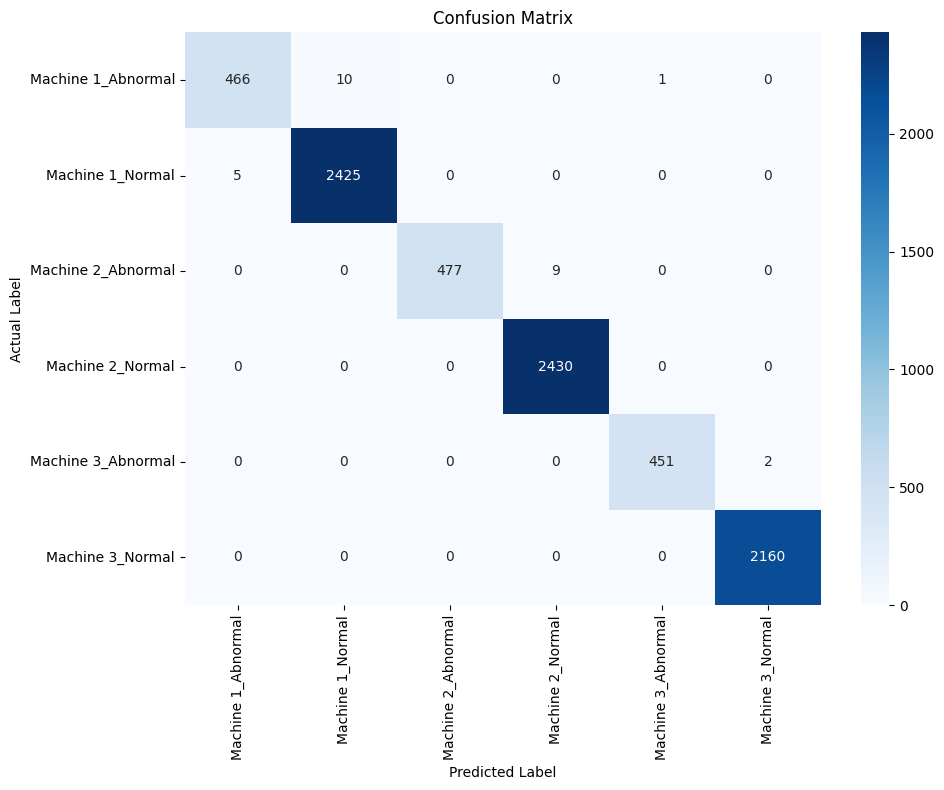

In [51]:
# Initialize the updated evaluator
evaluator = ModelEvaluator(
    model=model, 
    test_loader=test_loader, 
    device=device, 
    class_names=label_encoder.classes_
)

#  Extract metrics, including the new timing_stats dictionary
test_loss, test_accuracy, actual_labels, predicted_labels, timing_stats = evaluator.evaluate()

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.2f}%\n")

# Print the text report with worst-case timing bounds
evaluator.print_report(actual_labels, predicted_labels, timing_stats)

#  Show the confusion matrix
evaluator.plot_confusion_matrix(actual_labels, predicted_labels)